### Sentiment Trends

방준영(20249184)

In [58]:
import json

import requests
import pandas as pd
import matplotlib.pyplot as plt


from config import *



In [59]:
query = {
    # "query" : {
    #     "match" : {
    #         "title" : "IBM"
    #     }
    # },
  "size": 0,
  "aggs": {
    "group_by_date": {
      "date_histogram": {
        "field": "created_at",
        "interval": "day"
      },
      "aggs": {
        "group_by_sentiment": {
          "terms": {
            "field": "sentiment.keyword"
          }
        }
      }
    }
  }
}

In [60]:
query = json.dumps(query)

In [61]:
resp = requests.get(
f"{OPENSEARCH_URL}/news/_search",
headers = OPENSEARCH_HEADERS,
data = query,
auth = OPENSEARCH_AUTH

)


In [62]:
resp

<Response [200]>

In [63]:
results = resp.json()

In [64]:
buckets = results['aggregations']['group_by_date']['buckets']

In [65]:
buckets


[]

In [66]:
buffer = []

for x in buckets:
    sents = x['group_by_sentiment']['buckets']

    entry = {}
    for t in sents:
        key = t['key']
        value = t['doc_count']
        entry[key] = value

    entry['date'] = x['key_as_string']

    buffer.append(entry)

In [67]:
df = pd.DataFrame(buffer)
df['date'] = pd.to_datetime(df['date'])
df = df.set_index('date')

df = df.dropna()


KeyError: 'date'

In [34]:
df


,neutral,positive,negative
date,,,
2024-09-01 00:00:00+00:00,771,163,52
2024-09-02 00:00:00+00:00,1676,575,177
2024-09-03 00:00:00+00:00,1183,345,92
2024-09-04 00:00:00+00:00,932,323,117
2024-09-05 00:00:00+00:00,954,288,105
2024-09-06 00:00:00+00:00,618,221,74
2024-09-07 00:00:00+00:00,133,14,16
2024-09-08 00:00:00+00:00,379,73,40
2024-09-09 00:00:00+00:00,824,279,96


In [35]:
plt.rcParams['figure.figsize'] = (10, 4)



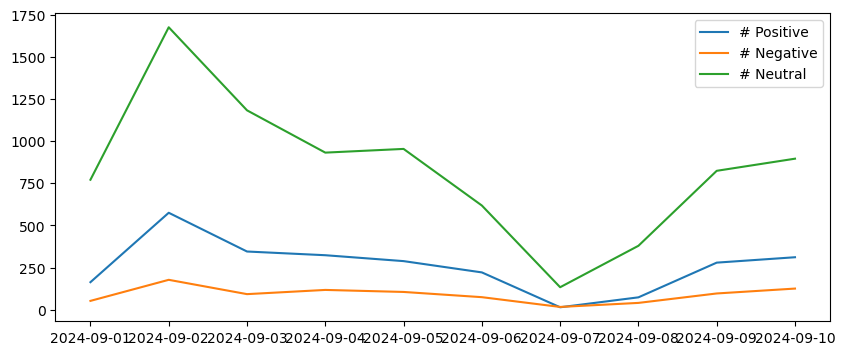

In [36]:
plt.plot(df['positive'], label = '# Positive')
plt.plot(df['negative'], label = '# Negative')
plt.plot(df['neutral'], label = '# Neutral')
plt.legend()
plt.show()


In [37]:
df['sentiment'] = (df['positive'] - df['negative']) / df.sum(axis=1)



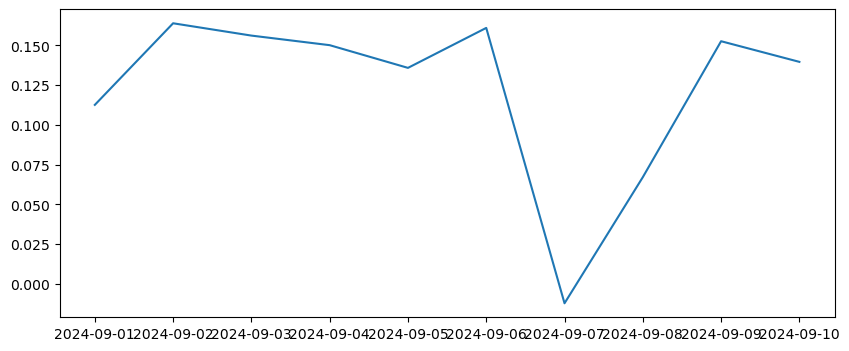

In [38]:
plt.plot(df['sentiment'])
plt.show()
